<a href="https://colab.research.google.com/github/JMQuinlan/Combustion/blob/main/adiabatic_flame_temperature_propane_const_P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAE 5202 - Combustion
Let's see how we can use Cantera to do the examples that we used to do with STANJAN.

copyright 2026 - J. M. Quinlan
University of Colorado
Colorado Springs

How does the Adiabatic flame temperature change depending on what we "pick" for the products?
How does it vary with equivalance ratio?

# Adiabatic Flame Temperature of Propane with Cantera

We compute $T_{ad}$ for C$_3$H$_8$–air for a **constant-pressure** process: the mixture burns
adiabatically at fixed $p$, so the products carry the same specific enthalpy as the reactants,

$$h(T_{ad},\, p_0,\, \mathbf{X}_{\text{prod}}) = h(T_0,\, p_0,\, \mathbf{X}_{\text{reac}})$$

This is the open-flame / deflagration idealization, and it is what Cantera's `equilibrate('HP')`
enforces — hold $h$ and $p$, solve for $T$ and the equilibrium composition.

The whole calculation is a *thermodynamic* one — no kinetics, no transport. We hold two
state variables fixed and let Cantera find the composition that minimizes Gibbs (or maximizes
entropy) subject to element conservation. The reaction mechanism only enters through
(a) which species are allowed to exist and (b) their NASA polynomial thermo data.

Install cantera

In [1]:
! pip install cantera matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.2 MB/s eta 0:00:00


In [2]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt

print("Cantera", ct.__version__)

MECH = "gri30.yaml"       # ships with Cantera; includes C3H8
FUEL = "C3H8"
AIR  = "O2:1.0, N2:3.76"  # dry air as a 2-component proxy

Cantera 3.2.0


## 1. Building the unburned mixture

`set_equivalence_ratio(phi, fuel, oxidizer)` does the stoichiometry bookkeeping for you: it
figures out the complete-combustion oxygen requirement from the element composition of the
fuel, then scales the fuel/oxidizer ratio by $\phi$. For propane the reference reaction is

$$\mathrm{C_3H_8} + 5\,(\mathrm{O_2} + 3.76\,\mathrm{N_2}) \rightarrow 3\,\mathrm{CO_2} + 4\,\mathrm{H_2O} + 18.8\,\mathrm{N_2}$$

so at $\phi = 1$ the fuel mole fraction should come out to $1/(1+5\cdot4.76) = 0.0403$.

A note on Cantera's API that trips people up coming from other libraries: a `Solution` object
is a *mutable state*, not a value. Assigning to a property pair (`gas.TP = ...`, `gas.HPX = ...`)
mutates the object in place and immediately re-solves for everything else. So order matters,
and a helper that returns a freshly-set object is the safest pattern.

In [3]:
def unburned(phi, T0=298.15, P0=ct.one_atm, mech=MECH):
    # Returns a Solution object set to the unburned propane/air state.
    gas = ct.Solution(mech)
    gas.TP = T0, P0
    gas.set_equivalence_ratio(phi, FUEL, AIR)
    return gas

gas = unburned(1.0)
X = gas.mole_fraction_dict()
print(f"phi = 1.0, T0 = {gas.T:.2f} K, p = {gas.P/ct.one_atm:.3f} atm")
for k in ("C3H8", "O2", "N2"):
    print(f"  X_{k:5s} = {X[k]:.4f}")
print(f"  mean MW  = {gas.mean_molecular_weight:.3f} kg/kmol")

phi = 1.0, T0 = 298.15 K, p = 1.000 atm
  X_C3H8  = 0.0403
  X_O2    = 0.2016
  X_N2    = 0.7581
  mean MW  = 29.466 kg/kmol


## 2. The constant-pressure result

`equilibrate('HP')` holds specific enthalpy and pressure fixed and solves for the equilibrium
temperature and composition. Because the mixture is adiabatic and no work is done other than
flow work, $h_{\text{products}} = h_{\text{reactants}}$ — that *is* the adiabatic flame condition.

In [9]:
gas = unburned(1.0)
h0 = gas.enthalpy_mass          # J/kg, conserved through the flame
gas.equilibrate("HP")

print(f"T_ad (HP, equilibrium) = {gas.T:8.2f} K")
print(f"enthalpy check: {gas.enthalpy_mass - h0:.3e} J/kg  (should be ~0)\n")

print("Equilibrium products (mole fractions > ppt):")
for name, x in sorted(gas.mole_fraction_dict().items(), key=lambda kv: -kv[1]):
    if x > 1e-12:
        print(f"  {name:6s} {x:8.12f}")

T_ad (HP, equilibrium) =  2265.70 K
enthalpy check: -4.912e-05 J/kg  (should be ~0)

Equilibrium products (mole fractions > ppt):
  N2     0.720805236162
  H2O    0.148483055129
  CO2    0.102710795029
  CO     0.012498437548
  O2     0.005879874929
  H2     0.003291733422
  OH     0.003210281282
  NO     0.002344482394
  H      0.000464006884
  O      0.000310781268
  HO2    0.000000611607
  NO2    0.000000460000
  N2O    0.000000125349
  H2O2   0.000000046428
  HNO    0.000000040563
  N      0.000000022774
  NH     0.000000003203
  NH3    0.000000002246
  HCO    0.000000001221
  NH2    0.000000001037
  NNH    0.000000000932
  HNCO   0.000000000518
  HCN    0.000000000029
  NCO    0.000000000028
  CH2O   0.000000000017
  HOCN   0.000000000002


Note what shows up alongside CO$_2$ and H$_2$O: about 1.2% CO, 0.6% leftover O$_2$, plus H$_2$,
OH and NO. At $\phi = 1$ there is exactly enough oxygen for complete combustion, so any O$_2$
in the products is direct evidence of **dissociation** — CO$_2$ and H$_2$O coming apart at high
temperature. Those reactions are endothermic, so they eat into the temperature.

## 3. How much does dissociation cost you?

To isolate the effect, compute the same flame temperature but *forbid* dissociation: freeze the
products at the complete-combustion composition and find the temperature at which their enthalpy
matches the reactants'.

The trick is `gas.HPX = h, P, X`. Setting the triplet with a composition means "fix $X$ and $p$,
then solve for the $T$ that gives this $h$" — a one-line replacement for the Newton iteration on
$\sum n_i h_i(T)$ you'd otherwise write by hand.

In [10]:
def T_complete_combustion(phi, T0=298.15, P0=ct.one_atm):
    # Frozen (no-dissociation) flame temperature; defined for lean/stoichiometric only.
    if phi > 1.0:
        raise ValueError("complete combustion is undefined for rich mixtures")
    gas = unburned(phi, T0, P0)
    h0 = gas.enthalpy_mass
    # per mole of fuel: 3 CO2, 4 H2O, (5/phi - 5) excess O2, 5*3.76/phi N2
    X = {"CO2": 3.0, "H2O": 4.0, "O2": 5.0 * (1.0 / phi - 1.0), "N2": 5.0 * 3.76 / phi}
    gas.HPX = h0, P0, X
    return gas.T

def T_equilibrium(phi, T0=298.15, P0=ct.one_atm, mode="HP"):
    gas = unburned(phi, T0, P0)
    gas.equilibrate(mode)
    return gas.T

T_eq   = T_equilibrium(1.0)
T_comp = T_complete_combustion(1.0)
print(f"complete combustion (no dissociation) : {T_comp:8.2f} K")
print(f"full chemical equilibrium             : {T_eq:8.2f} K")
print(f"dissociation penalty                  : {T_comp - T_eq:8.2f} K")

complete combustion (no dissociation) :  2392.10 K
full chemical equilibrium             :  2265.70 K
dissociation penalty                  :   126.40 K


~127 K, or about 5%. This is why hand calculations from a table of heats of formation always
overshoot, and it grows quickly with temperature — for stoichiometric H$_2$–O$_2$ or acetylene
flames the penalty is many hundreds of kelvin.

## 4. Sweeping equivalence ratio

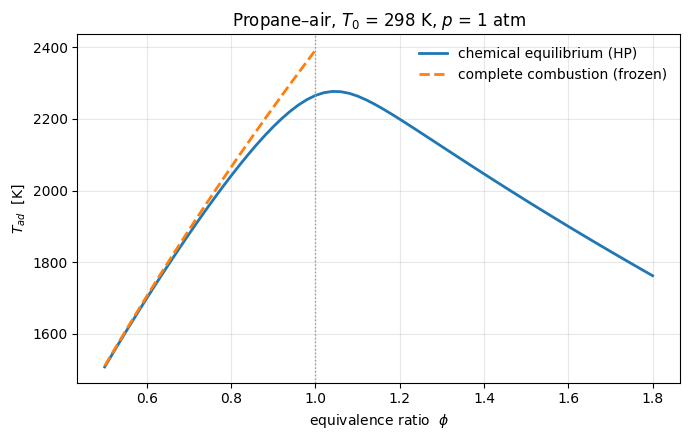

In [11]:
phis = np.linspace(0.5, 1.8, 66)
T_hp = np.array([T_equilibrium(p) for p in phis])
T_cc = np.array([T_complete_combustion(p) if p <= 1.0 else np.nan for p in phis])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(phis, T_hp, lw=2, label="chemical equilibrium (HP)")
ax.plot(phis, T_cc, lw=2, ls="--", label="complete combustion (frozen)")
ax.axvline(1.0, color="0.6", lw=1, ls=":")
ax.set_xlabel(r"equivalence ratio  $\phi$")
ax.set_ylabel(r"$T_{ad}$  [K]")
ax.set_title(r"Propane–air, $T_0$ = 298 K, $p$ = 1 atm")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Where is the peak?

The maximum sits slightly **rich** of stoichiometric, not at $\phi = 1$. Two effects push it there:

1. Dissociation is worst where the temperature is highest, and adding a little excess fuel
   consumes the leftover radical pool (O, OH, O$_2$) that dissociation keeps producing.
2. Rich products contain more CO and H$_2$ — light molecules with lower molar heat capacity than
   CO$_2$ and H$_2$O — so the same released enthalpy spreads over a lower $\bar{c}_p$.

In [12]:
phis_fine = np.linspace(0.95, 1.20, 51)
T_fine = np.array([T_equilibrium(p) for p in phis_fine])
i = T_fine.argmax()
print(f"peak T_ad = {T_fine[i]:.1f} K at phi = {phis_fine[i]:.3f}")
print(f"vs.  phi = 1.000 -> {T_equilibrium(1.0):.1f} K")

peak T_ad = 2277.1 K at phi = 1.045
vs.  phi = 1.000 -> 2265.7 K


## 6. Effect of preheat and pressure

Two sensitivities worth having a feel for:

- **Preheat.** Raising $T_0$ raises $T_{ad}$, but by *less* than the preheat itself
  ($dT_{ad}/dT_0 < 1$), because hotter products dissociate more and $c_p$ rises with temperature.
- **Pressure.** Equilibrium dissociation of CO$_2$ and H$_2$O increases the number of moles, so by
  Le Chatelier higher pressure suppresses it and nudges $T_{ad}$ up. The effect is real but weak —
  a factor of 10 in pressure buys only a few tens of kelvin. (This is also why the
  complete-combustion estimate is pressure-independent.)

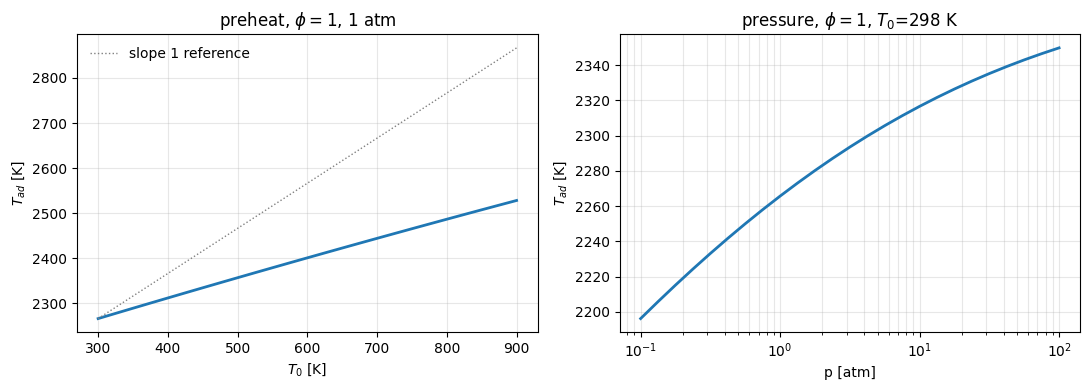

dT_ad/dT_0 (average over 300-900 K): 0.436
T_ad at 0.1 atm: 2196.2 K   at 100 atm: 2349.9 K


In [13]:
T0s = np.linspace(300, 900, 25)
T_preheat = np.array([T_equilibrium(1.0, T0=t) for t in T0s])

Ps = np.logspace(-1, 2, 25) * ct.one_atm   # 0.1 to 100 atm
T_press = np.array([T_equilibrium(1.0, P0=p) for p in Ps])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(T0s, T_preheat, lw=2)
axes[0].plot(T0s, T_preheat[0] + (T0s - T0s[0]), lw=1, ls=":", color="0.5",
             label=r"slope 1 reference")
axes[0].set_xlabel(r"$T_0$ [K]"); axes[0].set_ylabel(r"$T_{ad}$ [K]")
axes[0].set_title(r"preheat, $\phi=1$, 1 atm"); axes[0].legend(frameon=False)

axes[1].semilogx(Ps / ct.one_atm, T_press, lw=2)
axes[1].set_xlabel("p [atm]"); axes[1].set_ylabel(r"$T_{ad}$ [K]")
axes[1].set_title(r"pressure, $\phi=1$, $T_0$=298 K")

for a in axes:
    a.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print(f"dT_ad/dT_0 (average over 300-900 K): {np.gradient(T_preheat, T0s).mean():.3f}")
print(f"T_ad at 0.1 atm: {T_press[0]:.1f} K   at 100 atm: {T_press[-1]:.1f} K")

## 7. Does the mechanism matter?

For equilibrium, the *kinetics* in the mechanism file are irrelevant — only the species list and
their thermo data are used. But the species list does matter: equilibrium can only distribute the
atoms among species you gave it. Here is the same calculation with a hand-picked 11-species set
built from GRI-Mech's own thermo, which shows how quickly the answer converges (and where it
doesn't).

In [14]:
full = ct.Solution(MECH)
keep = ["C3H8", "O2", "N2", "CO2", "H2O", "CO", "H2", "OH", "H", "O", "NO"]
sub_species = [full.species(s) for s in keep]

def T_subset(phi, T0=298.15, P0=ct.one_atm):
    gas = ct.Solution(thermo="ideal-gas", species=sub_species)
    gas.TP = T0, P0
    gas.set_equivalence_ratio(phi, FUEL, AIR)
    gas.equilibrate("HP")
    return gas.T

print(f"{'phi':>6} {'GRI-Mech 3.0 (53 sp)':>22} {'11-species subset':>20} {'diff [K]':>10}")
for phi in (0.7, 1.0, 1.5, 2.0, 3.0):
    a, b = T_equilibrium(phi), T_subset(phi)
    print(f"{phi:6.2f} {a:22.2f} {b:20.2f} {a-b:10.2f}")

   phi   GRI-Mech 3.0 (53 sp)    11-species subset   diff [K]
  0.70                1878.71              1878.71      -0.01
  1.00                2265.70              2265.71      -0.00
  1.50                1972.25              1972.25       0.00
  2.00                1632.41              1632.41       0.00
  3.00                1079.96              1068.02      11.94


Through the practically interesting range the two agree to within hundredths of a kelvin. The
minor radicals are present in small enough amounts that they carry negligible enthalpy, and the
11 species are enough to do the atom bookkeeping correctly. The gap only opens at deeply rich
conditions — at $\phi = 3$ the full mechanism runs ~12 K hotter because it can form CH$_4$, an
exothermic sink for carbon that the reduced set has no room for.

The practical lesson: for equilibrium you need the right *thermo*, and enough species to let the
atoms go where they want. You do not need a large mechanism.

**Caveats worth keeping in mind:**

- GRI-Mech 3.0 was optimized for natural gas. Its *thermo* data for C$_3$H$_8$ is standard and
  fine for equilibrium, but if you move on to flame speeds or ignition delays, use a mechanism
  actually validated for propane (USC Mech II, AramcoMech, or a reduced C$_3$ mechanism).
- No condensed phases here. Above roughly $\phi \approx 2.5$ real propane flames form solid
  carbon, and a gas-only equilibrium will overpredict the temperature. Cantera handles that with
  `ct.Mixture` across a gas phase plus `graphite.yaml`.
- Dry air only. Ambient humidity is worth ~10–20 K.
- "Adiabatic" excludes radiation. Measured flame temperatures typically land 100–200 K below
  $T_{ad}$ even in well-insulated burners.

## 8. Reference table

Sanity check against handbook values — stoichiometric propane–air from 298 K is usually quoted
around 2260–2270 K.

In [15]:
fuels = {"CH4": "methane", "C3H8": "propane", "C2H4": "ethylene", "C2H2": "acetylene", "H2": "hydrogen"}

print(f"{'fuel':>10} {'T_ad [K]':>10}    (stoichiometric, 298 K, 1 atm, const. p)")
for f, label in fuels.items():
    g = ct.Solution(MECH)
    g.TP = 298.15, ct.one_atm
    g.set_equivalence_ratio(1.0, f, AIR)
    g.equilibrate("HP")
    print(f"{label:>10} {g.T:10.1f}")

      fuel   T_ad [K]    (stoichiometric, 298 K, 1 atm, const. p)
   methane     2224.6
   propane     2265.7
  ethylene     2368.6
 acetylene     2539.7
  hydrogen     2379.9


## Where to take this next

- `ct.FreeFlame` on the same gas object gives you the laminar flame speed and the full 1-D
  structure — the unburned state you built above is exactly the inlet condition it wants.
- `ct.IdealGasConstPressureReactor` + `ct.ReactorNet` gives the *transient* constant-pressure
  path to this same endpoint — the T(t) history and ignition delay — which is where the kinetics
  finally matter. The equilibrium temperature above is the asymptote that integration converges to.
- `gas.equilibrate('TP')` at a fixed temperature is useful for emissions work: it tells you the
  equilibrium NO or CO your products are relaxing toward.